# Cross-Country Flights: Price Change Modeling ✈️
## Notebook 2: EDA
### Will Bartlett & Kevin Tran

This notebook shows exploratory data analysis of flight price data from over 600,000 observations of cross-country flights.

### 1. Get Data From Dropbox
<b>NOTE:</b> Gets all .csv files from Dropbox, not from the sample data in the <i>data</i> folder of the repository

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dropbox
import os
import io
from dropbox.exceptions import ApiError
from scipy import stats

In [142]:
# Save dropbox credentials
DROPBOX_APP_KEY = "9gghuhtkyrtyn2u"
DROPBOX_APP_SECRET = "tqtvwbr15gbwseg"
DROPBOX_REFRESH_TOKEN = "LpMKV__by1wAAAAAAAAAAYn_oi2fIW0SBBqF0n6gap1WavDnJGFRMcVWQol7X5Vy"

# Create Dropbox client
dbx = dropbox.Dropbox(
    app_key=DROPBOX_APP_KEY,
    app_secret=DROPBOX_APP_SECRET,
    oauth2_refresh_token=DROPBOX_REFRESH_TOKEN
)

print("Reading files from Dropbox...")

# List all files
result = dbx.files_list_folder('/flight_data')

dfs = []
for entry in result.entries:
    if entry.name.endswith('.csv'):
        print(f"Reading: {entry.name}")
        
        # Download file content
        metadata, response = dbx.files_download(entry.path_lower)
        
        # Read directly into pandas
        df = pd.read_csv(io.BytesIO(response.content))
        dfs.append(df)

# Combine
combined_df = pd.concat(dfs, ignore_index=True)

# Process
combined_df['route'] = combined_df['origin'] + ' → ' + combined_df['destination']
combined_df['time_collected'] = pd.to_datetime(combined_df['time_collected'])
combined_df['departure_date'] = pd.to_datetime(combined_df['departure_date'])
df = combined_df.copy()

# Convert to datetime with error handling
try:
    if df['departure_date'].dtype != 'datetime64[ns]':
        df['departure_date'] = pd.to_datetime(df['departure_date'], errors='coerce')
except Exception as e:
    print(f"Error with departure_date: {e}")
    # Try alternative parsing
    df['departure_date'] = pd.to_datetime(df['departure_date'].astype(str), errors='coerce')

try:
    if df['departure_time'].dtype != 'datetime64[ns]':
        df['departure_time'] = pd.to_datetime(df['departure_time'], errors='coerce')
except Exception as e:
    print(f"Error with departure_time: {e}")
    df['departure_time'] = pd.to_datetime(df['departure_time'].astype(str), errors='coerce')

try:
    if df['time_collected'].dtype != 'datetime64[ns]':
        df['time_collected'] = pd.to_datetime(df['time_collected'], errors='coerce')
except Exception as e:
    print(f"Error with time_collected: {e}")
    df['time_collected'] = pd.to_datetime(df['time_collected'].astype(str), errors='coerce')

# Round departure time to nearest 15 minutes (flights might vary by a few minutes)
df['departure_time_rounded'] = df['departure_time'].dt.floor('15min')

# Create flight ID for each unique flight
df['flight_id'] = (
    df['origin'].astype(str) + '_' + 
    df['destination'].astype(str) + '_' + 
    df['departure_date'].dt.strftime('%Y%m%d') + '_' + 
    df['departure_time_rounded'].dt.strftime('%H%M') + '_' + 
    df['airline'].astype(str)
)
df.head()

Reading files from Dropbox...
Reading: flight_data_20251110_210135.csv
Reading: flight_data_20251111_031726.csv
Reading: flight_data_20251111_130430.csv
Reading: flight_data_20251112_021940.csv
Reading: flight_data_20251112_130852.csv
Reading: flight_data_20251113_022155.csv
Reading: flight_data_20251113_130822.csv
Reading: flight_data_20251114_022042.csv
Reading: flight_data_20251114_130600.csv
Reading: flight_data_20251115_021721.csv
Reading: flight_data_20251115_125944.csv
Reading: flight_data_20251116_022726.csv
Reading: flight_data_20251116_125744.csv
Reading: flight_data_20251117_022452.csv
Reading: flight_data_20251117_132325.csv
Reading: flight_data_20251118_025158.csv
Reading: flight_data_20251118_130553.csv
Reading: flight_data_20251119_021933.csv
Reading: flight_data_20251119_130946.csv
Reading: flight_data_20251120_021830.csv
Reading: flight_data_20251120_130617.csv
Reading: flight_data_20251121_022030.csv
Reading: flight_data_20251121_130024.csv
Reading: flight_data_202511

,time_collected,origin,destination,departure_date,days_until_departure,price,currency,airline,number_of_stops,departure_time,arrival_time,total_duration,aircraft_type,cabin_class,bookable_seats,route,departure_time_rounded,flight_id
0,2025-11-10 20:41:58,JFK,LAX,2025-11-11,1,144.27,EUR,F9,1,2025-11-11 06:25:00,2025-11-11T12:25:00,PT9H,"32Q,32Q",ECONOMY,4,JFK → LAX,2025-11-11 06:15:00,JFK_LAX_20251111_0615_F9
1,2025-11-10 20:41:58,JFK,LAX,2025-11-11,1,149.13,EUR,F9,1,2025-11-11 07:59:00,2025-11-11T19:53:00,PT14H54M,"32Q,32Q",ECONOMY,4,JFK → LAX,2025-11-11 07:45:00,JFK_LAX_20251111_0745_F9
2,2025-11-10 20:41:58,JFK,LAX,2025-11-11,1,149.13,EUR,F9,1,2025-11-11 07:59:00,2025-11-11T20:42:00,PT15H43M,"32Q,32N",ECONOMY,4,JFK → LAX,2025-11-11 07:45:00,JFK_LAX_20251111_0745_F9
3,2025-11-10 20:41:58,JFK,LAX,2025-11-11,1,210.02,EUR,F9,0,2025-11-11 11:29:00,2025-11-11T14:32:00,PT6H3M,32Q,ECONOMY,4,JFK → LAX,2025-11-11 11:15:00,JFK_LAX_20251111_1115_F9
4,2025-11-10 20:41:58,JFK,LAX,2025-11-11,1,256.07,EUR,AS,1,2025-11-11 07:00:00,2025-11-11T15:17:00,PT11H17M,"73H,73J",ECONOMY,7,JFK → LAX,2025-11-11 07:00:00,JFK_LAX_20251111_0700_AS


In [143]:
df.shape

(616766, 18)

In [144]:
df.describe()

,time_collected,departure_date,days_until_departure,price,number_of_stops,departure_time,bookable_seats,departure_time_rounded
count,616766,616766,616766.000000,616766.000000,616766.000000,616766,616766.000000,616766
mean,2025-11-27 04:33:01.568042752,2025-12-04 08:34:08.937847296,7.494794,493.405398,0.884421,2025-12-04 21:32:07.821733888,5.445441,2025-12-04 21:27:13.749104384
min,2025-11-10 20:41:58,2025-11-11 00:00:00,1.000000,33.620000,0.000000,2025-11-11 00:20:00,1.000000,2025-11-11 00:15:00
25%,2025-11-16 12:48:03,2025-11-24 00:00:00,4.000000,262.400000,1.000000,2025-11-24 10:00:00,3.000000,2025-11-24 10:00:00
50%,2025-11-30 12:52:33,2025-12-06 00:00:00,7.000000,389.400000,1.000000,2025-12-06 05:05:00,7.000000,2025-12-06 05:00:00
75%,2025-12-07 02:22:08,2025-12-14 00:00:00,11.000000,561.140000,1.000000,2025-12-14 16:07:00,9.000000,2025-12-14 16:00:00
max,2025-12-13 12:58:00,2025-12-27 00:00:00,14.000000,9615.080000,2.000000,2025-12-27 23:59:00,9.000000,2025-12-27 23:45:00
std,NaN,NaN,4.034239,587.436518,0.322361,NaN,3.174059,NaN


In [145]:
# Convert prices to USD
df['price'] = df['price'] * 1.15 #1.15 is exchange rate

### 2. Basic Price EDA

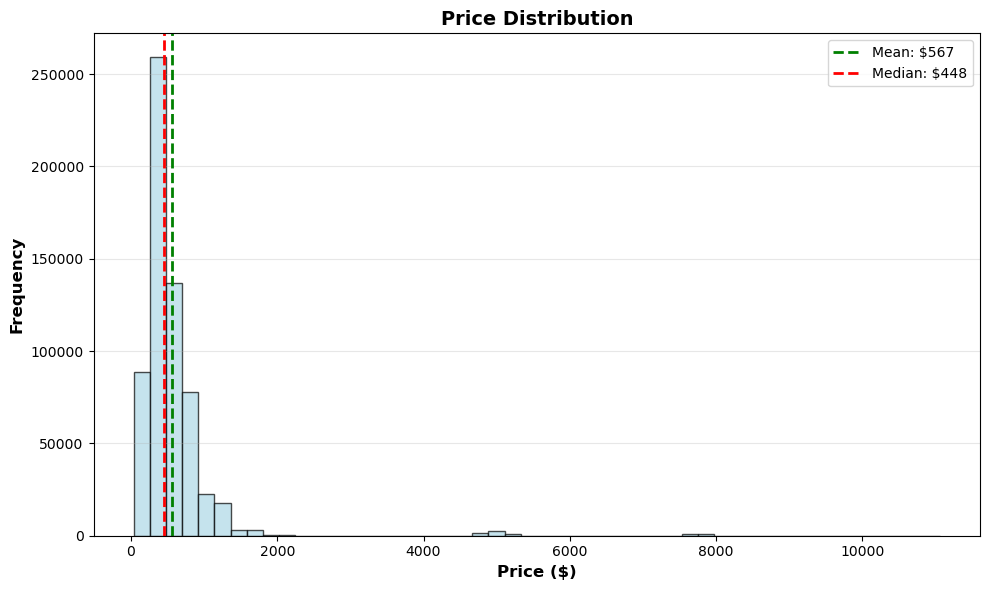

In [146]:
# Histogram
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.hist(df['price'], bins=50, color='lightblue', edgecolor='black', alpha=0.7)
ax1.axvline(df['price'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: ${df["price"].mean():.0f}')
ax1.axvline(df['price'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: ${df["price"].median():.0f}')
ax1.set_xlabel('Price ($)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Price Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 3. Airline-Level EDA

In [147]:
# Save airline names from the codes
airlines = {
    'F9': 'Frontier Airlines',
    'B6': 'JetBlue', 
    'UA': 'United Airlines',
    'HA': 'Hawaiian Airlines',
    'AS': 'Alaska Airlines'
}
df['airline_code'] = df['airline']
df = df.drop(columns=['airline'])
df['airline'] = df['airline_code'].map(airlines)

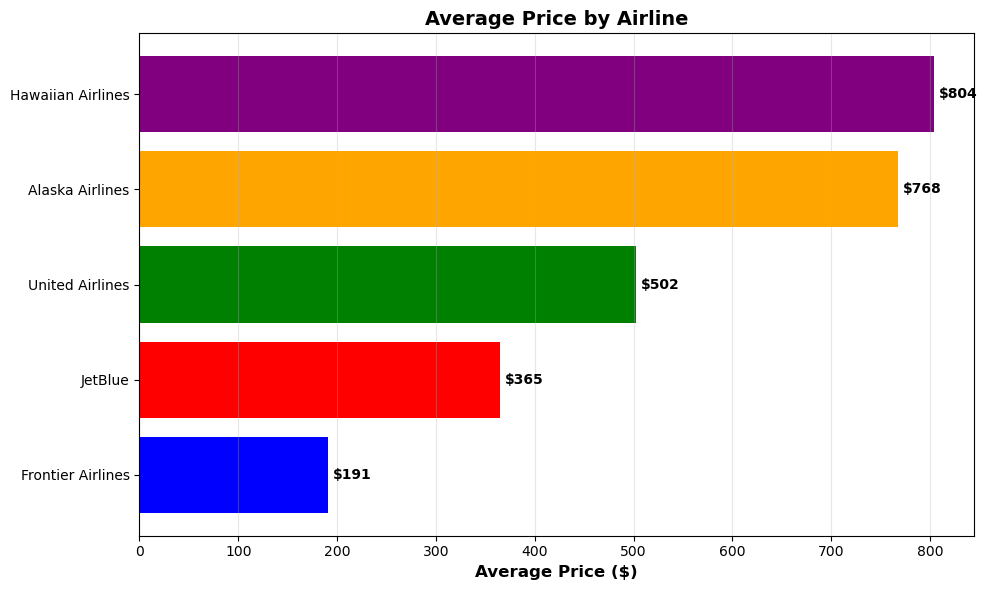

In [148]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Average price by airline
airline_stats = df.groupby('airline').agg({
    'price': ['mean', 'median', 'std', 'count']
}).round(0)
airline_stats.columns = ['mean', 'median', 'std', 'count']
airline_stats = airline_stats.sort_values('mean')

bars = ax1.barh(airline_stats.index, airline_stats['mean'], 
               color=['blue', 'red', 'green', 'orange', 'purple'][:len(airline_stats)])
ax1.set_xlabel('Average Price ($)', fontsize=12, fontweight='bold')
ax1.set_title('Average Price by Airline', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
for i, (idx, row) in enumerate(airline_stats.iterrows()):
    ax1.text(row['mean'] + 5, i, f"${row['mean']:.0f}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

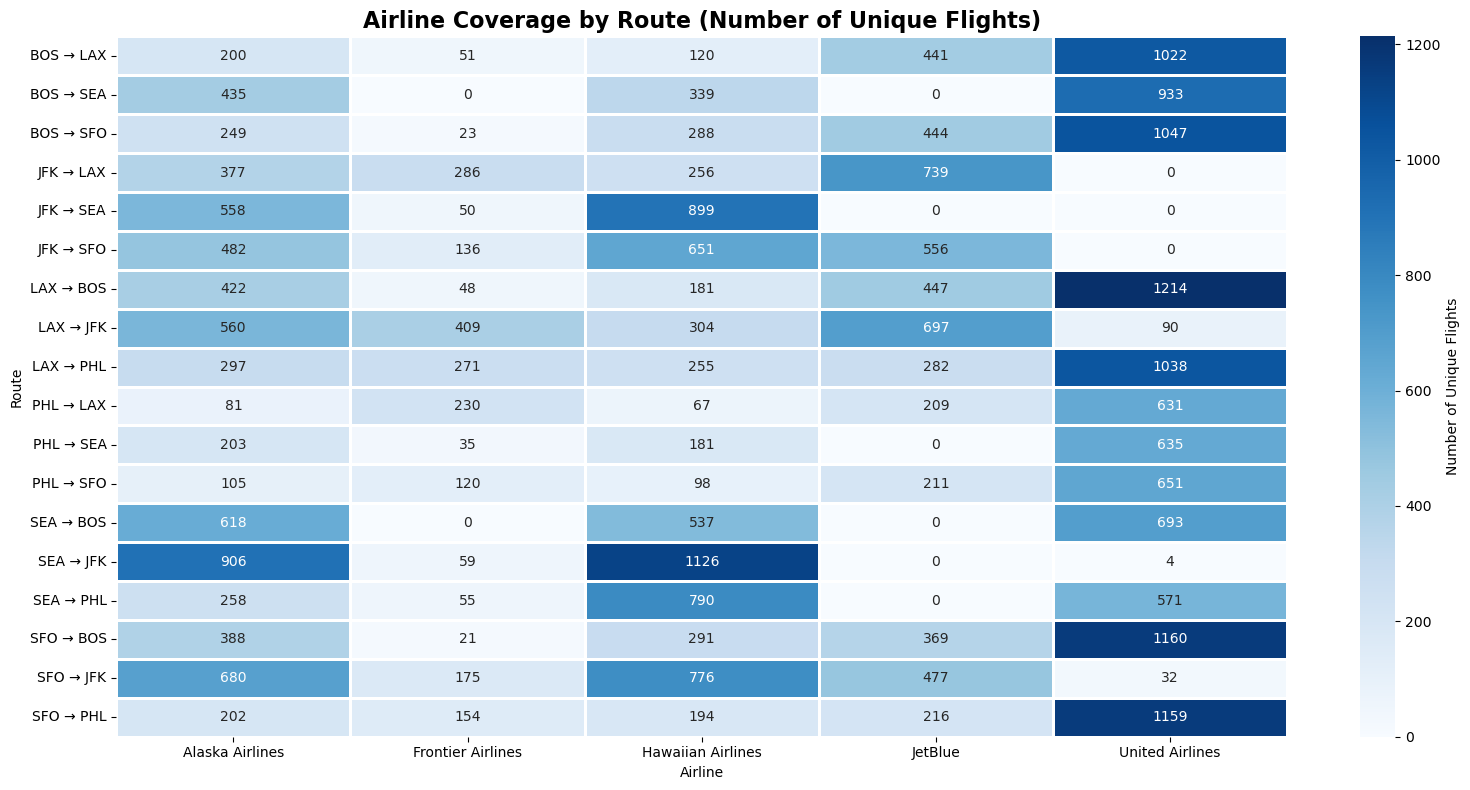

In [149]:
# Airline coverage by route: number of unique flights per airline per route
coverage = df.groupby(['route', 'airline'])['flight_id'].nunique().unstack(fill_value=0)
plt.figure(figsize=(16, 8))
sns.heatmap(coverage, annot=True, fmt='d', cmap='Blues', linewidths=1, cbar_kws={'label': 'Number of Unique Flights'})
plt.title('Airline Coverage by Route (Number of Unique Flights)', fontsize=16, fontweight='bold')
plt.xlabel('Airline')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

### 4. Route-Level EDA

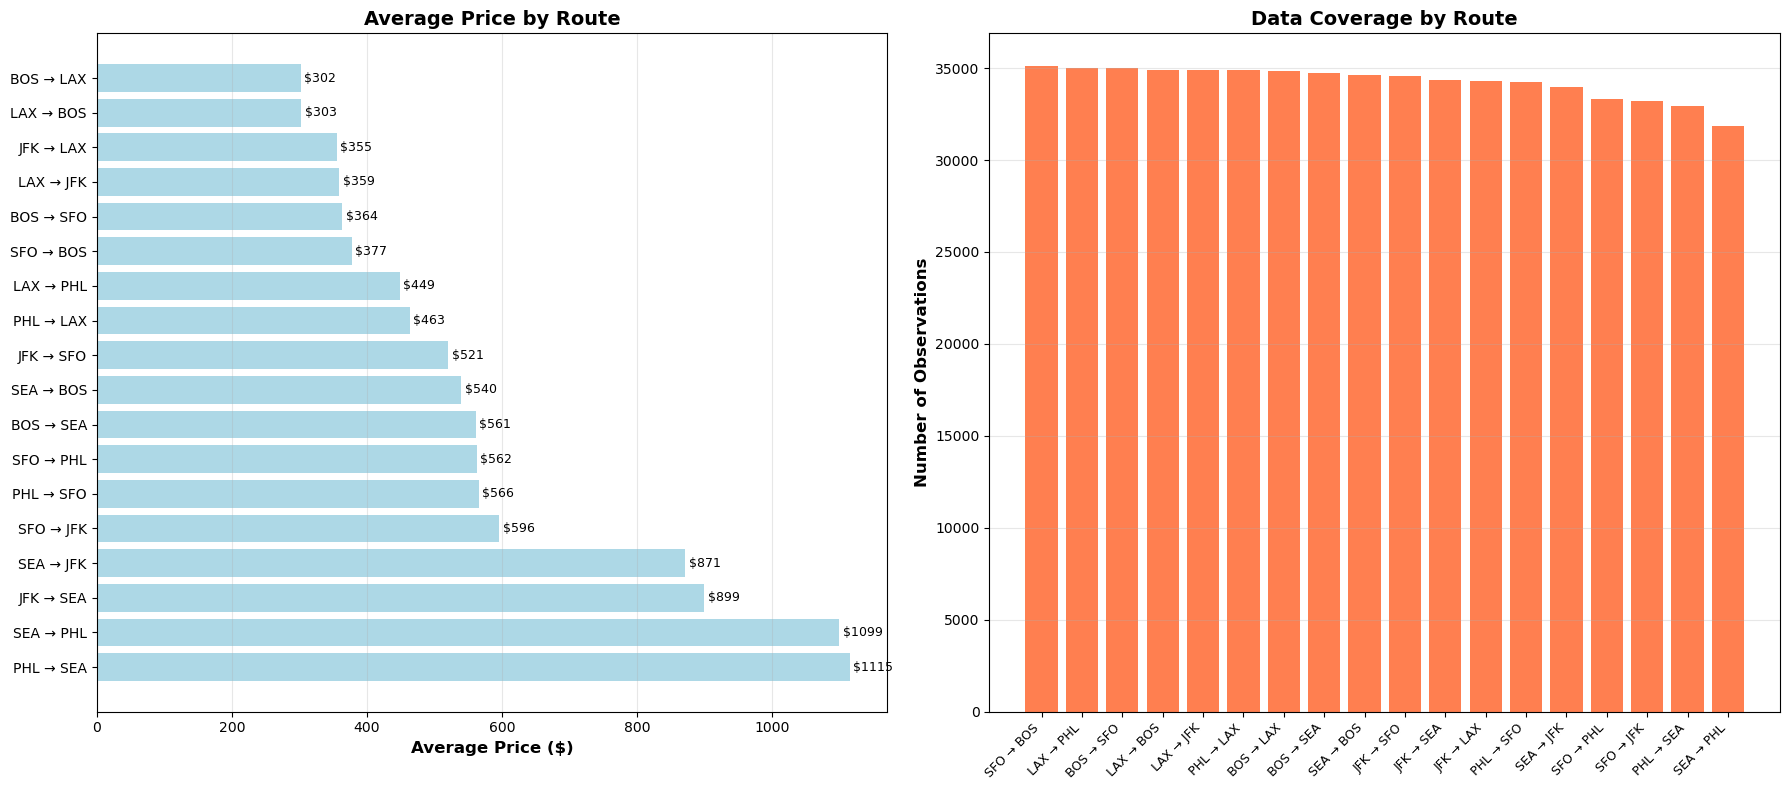

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Average price by route
ax1 = axes[0]
route_prices = df.groupby('route')['price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
bars = ax1.barh(route_prices.index, route_prices['mean'], color='lightblue')
ax1.set_xlabel('Average Price ($)', fontsize=12, fontweight='bold')
ax1.set_title('Average Price by Route', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
for i, (idx, row) in enumerate(route_prices.iterrows()):
    ax1.text(row['mean'] + 5, i, f"${row['mean']:.0f}", va='center', fontsize=9)

# Data coverage by route
ax2 = axes[1]
route_counts = df.groupby('route').size().sort_values(ascending=False)
ax2.bar(range(len(route_counts)), route_counts.values, color='coral')
ax2.set_xticks(range(len(route_counts)))
ax2.set_xticklabels(route_counts.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Number of Observations', fontsize=12, fontweight='bold')
ax2.set_title('Data Coverage by Route', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

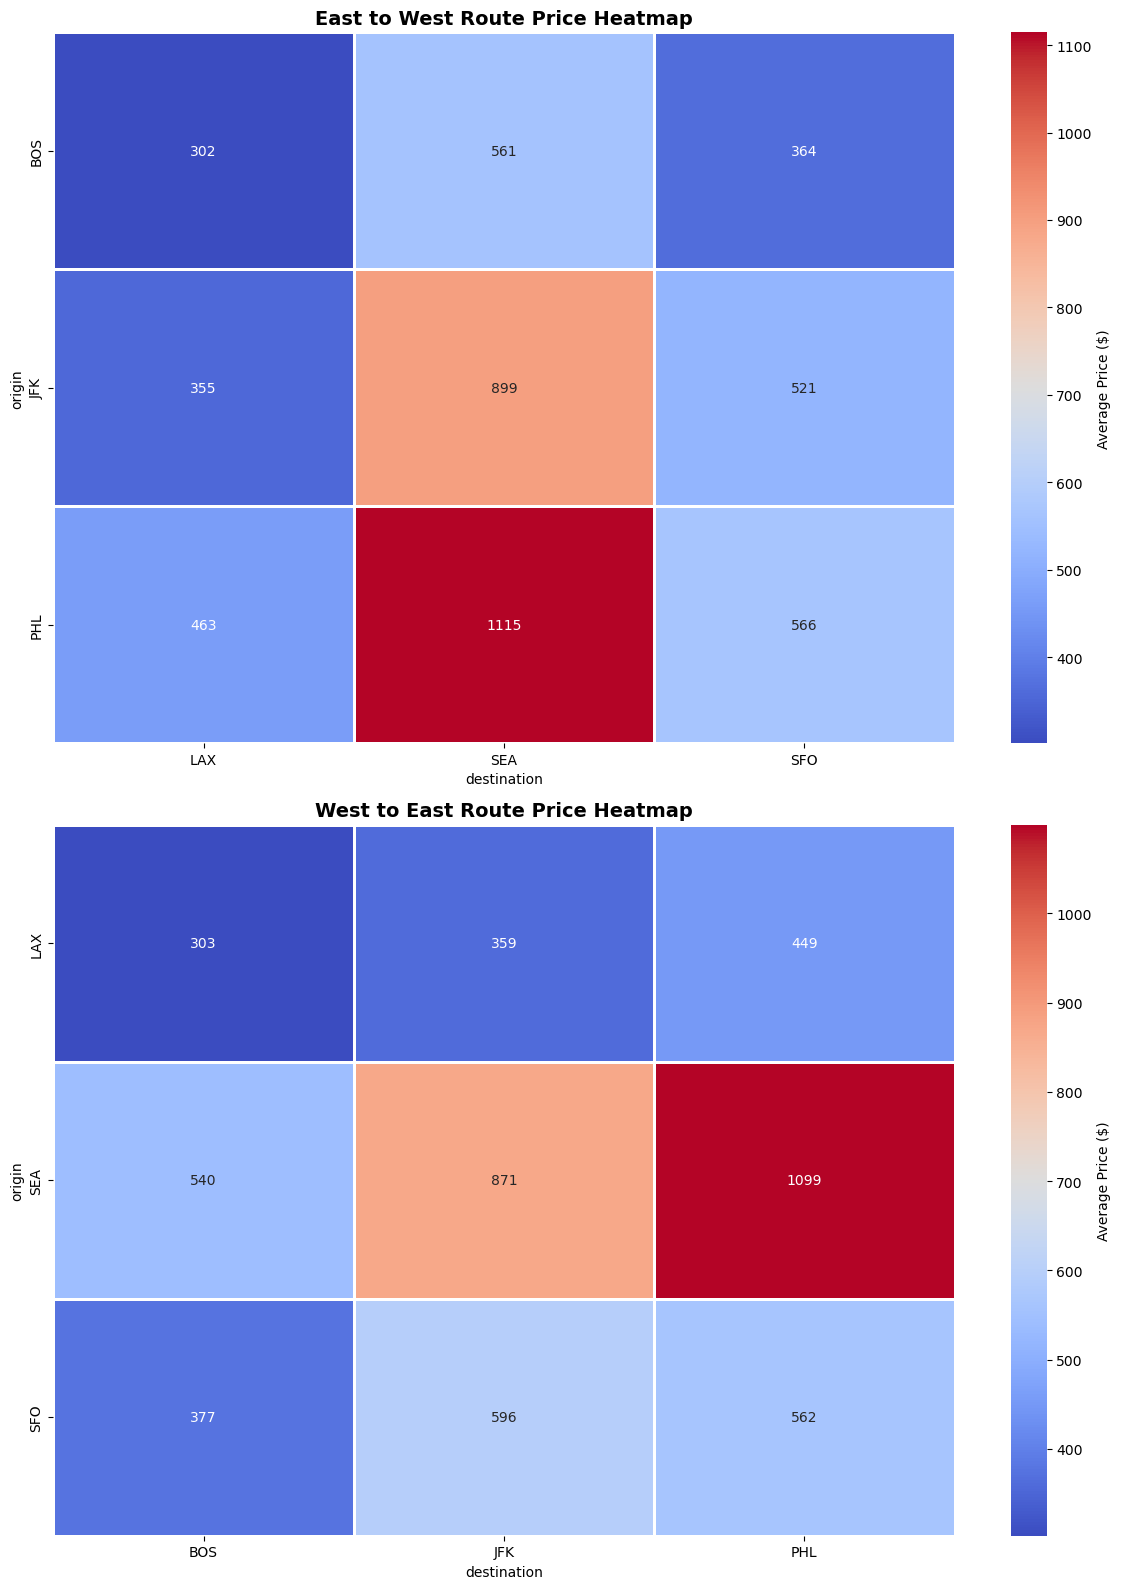

In [151]:
# Define east and west airports (customize as needed)
east_airports = ['JFK',  'BOS', 'PHL']
west_airports = ['LAX', 'SFO', 'SEA']

# East to West routes
df_east_west = df[df['origin'].isin(east_airports) & df['destination'].isin(west_airports)]
pivot_east_west = df_east_west.pivot_table(values='price', index='origin', columns='destination', aggfunc='mean')

# West to East routes
df_west_east = df[df['origin'].isin(west_airports) & df['destination'].isin(east_airports)]
pivot_west_east = df_west_east.pivot_table(values='price', index='origin', columns='destination', aggfunc='mean')

fig, axes = plt.subplots(2, 1, figsize=(12, 16))

sns.heatmap(pivot_east_west, annot=True, fmt='.0f', cmap='coolwarm', ax=axes[0],
           cbar_kws={'label': 'Average Price ($)'}, linewidths=2)
axes[0].set_title('East to West Route Price Heatmap', fontsize=14, fontweight='bold')

sns.heatmap(pivot_west_east, annot=True, fmt='.0f', cmap='coolwarm', ax=axes[1],
           cbar_kws={'label': 'Average Price ($)'}, linewidths=2)
axes[1].set_title('West to East Route Price Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 5. Days Until Departure EDA

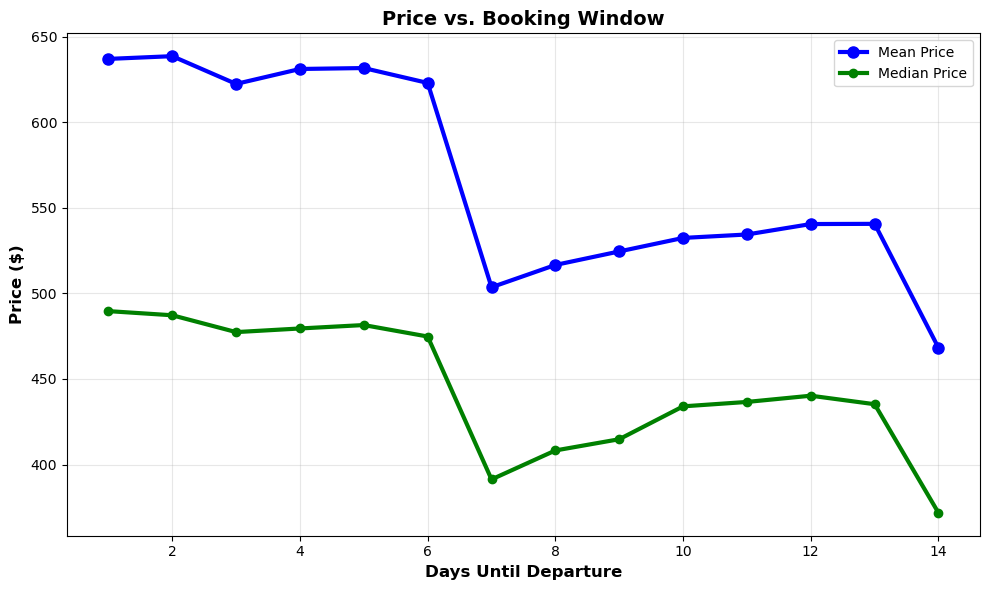

In [152]:
fig, ax1 = plt.subplots(figsize=(10, 6))
booking_stats = df.groupby('days_until_departure').agg({
    'price': ['mean', 'median', 'std', 'count']
}).round(2)
booking_stats.columns = ['mean', 'median', 'std', 'count']

ax1.plot(booking_stats.index, booking_stats['mean'], marker='o', linewidth=3, 
         markersize=8, color='blue', label='Mean Price')
ax1.plot(booking_stats.index, booking_stats['median'], marker='o', linewidth=3, 
         markersize=6, color='green',  label='Median Price')

ax1.set_xlabel('Days Until Departure', fontsize=12, fontweight='bold')
ax1.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax1.set_title('Price vs. Booking Window', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Temporal EDA

/var/folders/dw/zsq0tshd17zfndgp1s_yw9zc0000gn/T/ipykernel_37176/4141996875.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_prices = df.groupby('departure_time_category')['price'].mean()


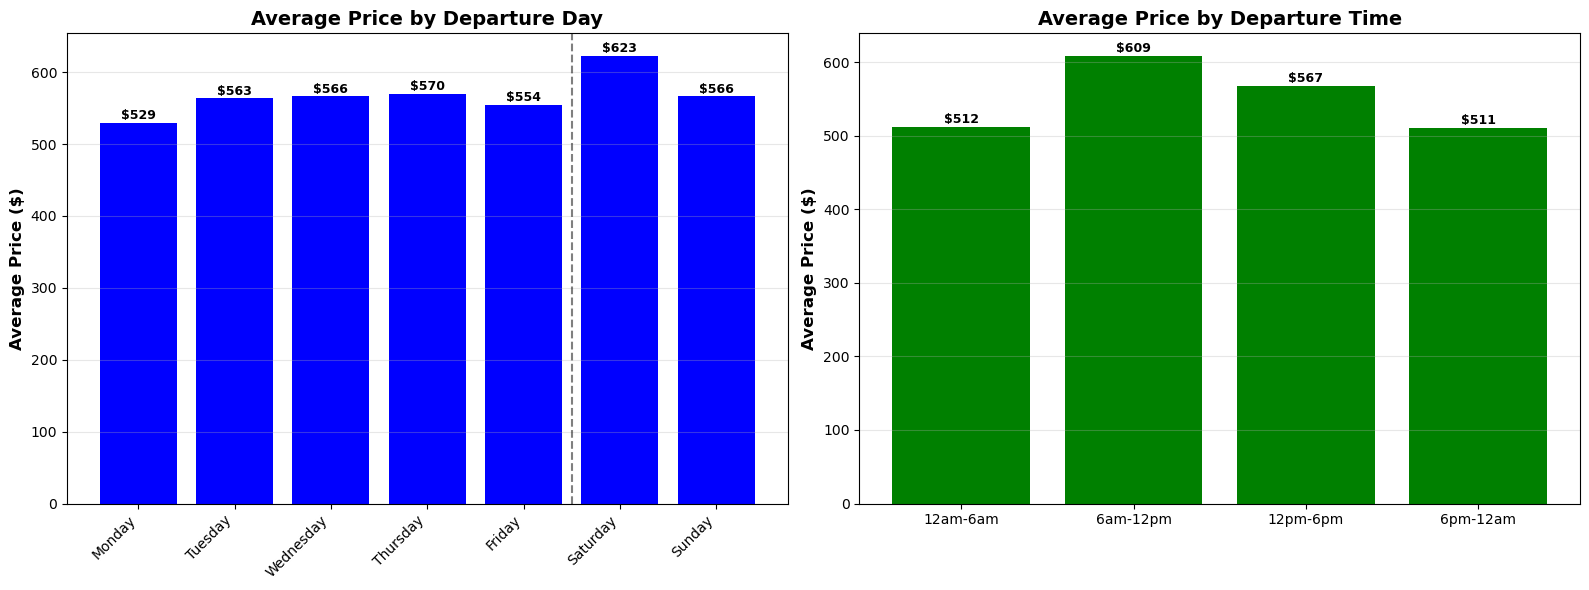

In [153]:
# Add temporal features
df['departure_hour'] = pd.to_datetime(df['departure_time']).dt.hour
df['day_of_week'] = df['departure_date'].dt.day_name()
df['departure_time_category'] = pd.cut(df['departure_hour'], 
                                       bins=[0, 6, 12, 18, 24],
                                       labels=['12am-6am', '6am-12pm', 
                                              '12pm-6pm', '6pm-12am'],
                                       include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price by day of week
ax1 = axes[0]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_prices = df.groupby('day_of_week')['price'].mean().reindex(day_order)
bars = ax1.bar(range(len(day_order)), day_prices.values,
              color=['blue']*7)
ax1.set_xticks(range(len(day_order)))
ax1.set_xticklabels(day_order, rotation=45, ha='right')
ax1.set_ylabel('Average Price ($)', fontsize=12, fontweight='bold')
ax1.set_title('Average Price by Departure Day', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.axvline(4.5, color='black', linestyle='--', alpha=0.5)
for i, val in enumerate(day_prices.values):
    ax1.text(i, val + 5, f'${val:.0f}', ha='center', fontsize=9, fontweight='bold')

# Price by departure time
ax2 = axes[1]
time_prices = df.groupby('departure_time_category')['price'].mean()
bars = ax2.bar(range(len(time_prices)), time_prices.values,
              color='green')
ax2.set_xticks(range(len(time_prices)))
ax2.set_xticklabels(time_prices.index)
ax2.set_ylabel('Average Price ($)', fontsize=12, fontweight='bold')
ax2.set_title('Average Price by Departure Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for i, val in enumerate(time_prices.values):
    ax2.text(i, val + 5, f'${val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 7. Number of Stops EDA

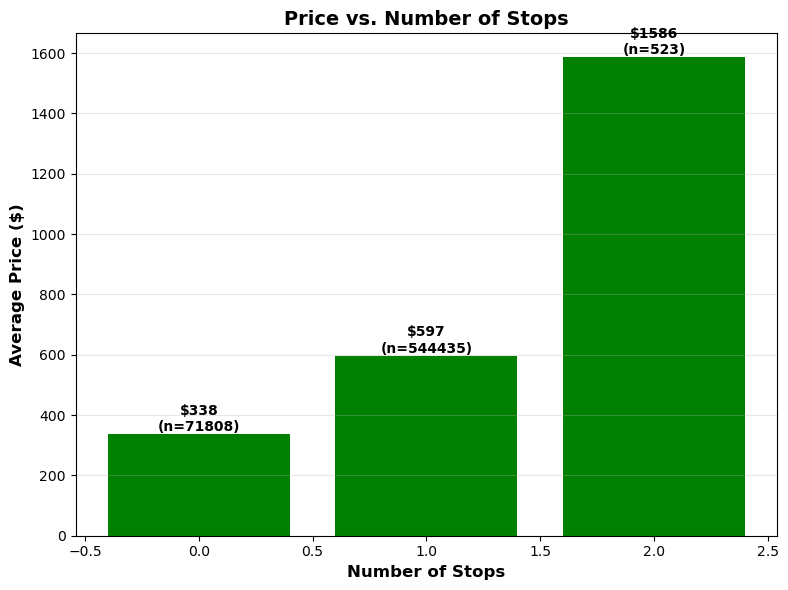

In [154]:
# Price vs. Number of Stops
stops_stats = df.groupby('number_of_stops').agg({
    'price': ['mean', 'count']
}).round(0)
stops_stats.columns = ['mean', 'count']
plt.figure(figsize=(8, 6))
bars = plt.bar(stops_stats.index, stops_stats['mean'], color='green')
plt.xlabel('Number of Stops', fontsize=12, fontweight='bold')
plt.ylabel('Average Price ($)', fontsize=12, fontweight='bold')
plt.title('Price vs. Number of Stops', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
for i, (idx, row) in enumerate(stops_stats.iterrows()):
    plt.text(idx, row['mean'] + 10, f"${row['mean']:.0f}\n(n={int(row['count'])})", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 8. Number of Bookable Seats EDA

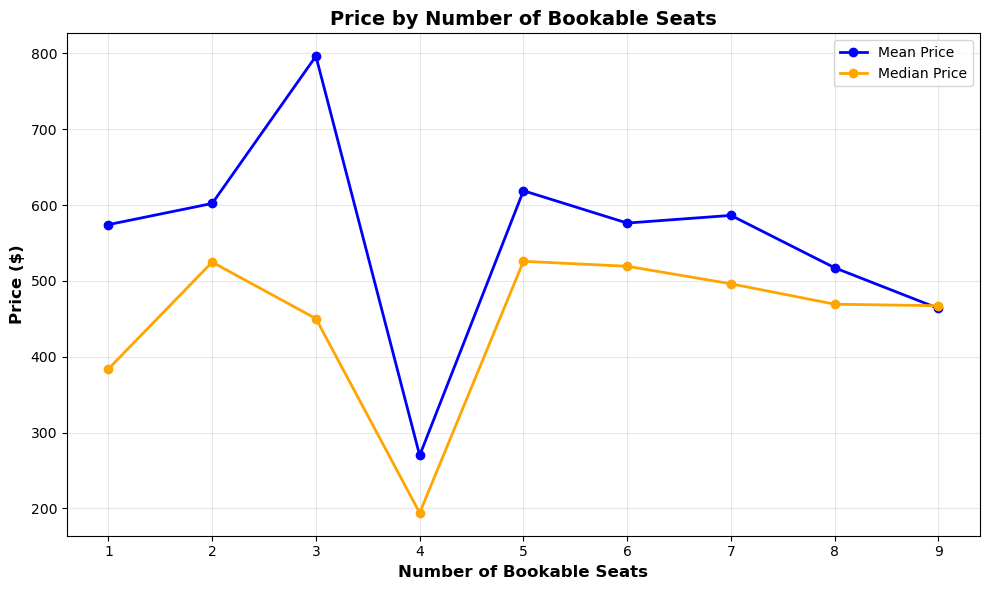

In [155]:
# Average price by number of bookable seats
seat_stats = df[df['bookable_seats'] > 0].groupby('bookable_seats')['price'].mean()
seat_median = df[df['bookable_seats'] > 0].groupby('bookable_seats')['price'].median()

plt.figure(figsize=(10, 6))
plt.plot(seat_stats.index, seat_stats.values, marker='o', color='blue', linewidth=2, label='Mean Price')
plt.plot(seat_median.index, seat_median.values, marker='o', color='orange', linewidth=2, label='Median Price')
plt.xlabel('Number of Bookable Seats', fontsize=12, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
plt.title('Price by Number of Bookable Seats', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

### 9. Price Change EDA

In [156]:
# Calculate unique flight statistics
total_observations = len(df)
unique_flights = df['flight_id'].nunique()
avg_observations_per_flight = total_observations / unique_flights

# Group by flight and calculate price statistics
flight_stats = df.groupby('flight_id').agg({
    'price': ['min', 'max', 'mean', 'std', 'count'],
    'origin': 'first',
    'destination': 'first',
    'departure_date': 'first',
    'airline': 'first',
    'time_collected': ['min', 'max']
}).round(2)

flight_stats.columns = ['price_min', 'price_max', 'price_mean', 'price_std', 'observations',
                        'origin', 'destination', 'departure_date', 'airline', 
                        'first_seen', 'last_seen']

# Calculate price volatility
flight_stats['price_range'] = flight_stats['price_max'] - flight_stats['price_min']
flight_stats['price_change_pct'] = (flight_stats['price_range'] / flight_stats['price_min'] * 100).round(1)
flight_stats['price_change_pct'] = flight_stats['price_change_pct'].replace([np.inf, -np.inf], 0)

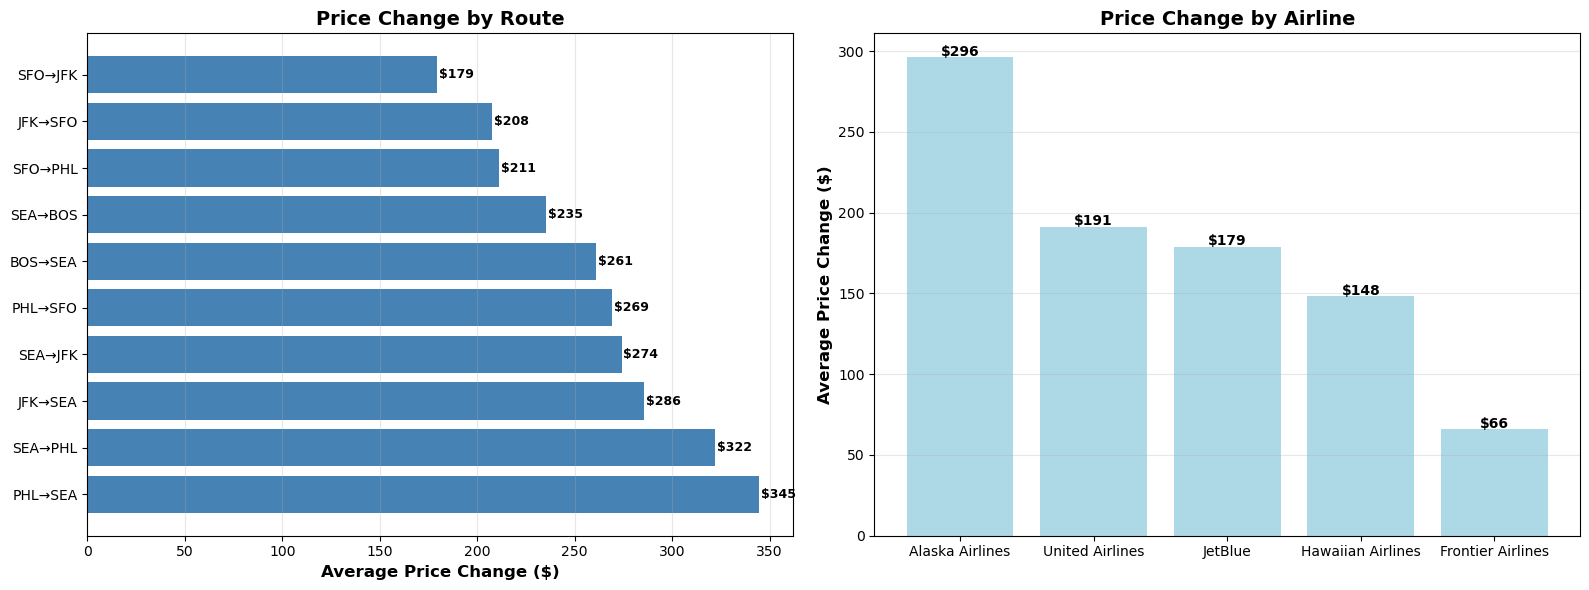

In [157]:
# Change to (1, 2) for horizontal stacking
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2c. Volatility by Route
ax3 = axes[0]  # First subplot (left)
route_volatility = flight_stats.groupby(['origin', 'destination'])['price_range'].mean().sort_values(ascending=False).head(10)
route_labels = [f"{o}→{d}" for o, d in route_volatility.index]
bars = ax3.barh(range(len(route_volatility)), route_volatility.values, color='steelblue')
ax3.set_yticks(range(len(route_volatility)))
ax3.set_yticklabels(route_labels, fontsize=10)
ax3.set_xlabel('Average Price Change ($)', fontsize=12, fontweight='bold')
ax3.set_title('Price Change by Route', 
             fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
for i, val in enumerate(route_volatility.values):
    ax3.text(val + 1, i, f'${val:.0f}', va='center', fontsize=9, fontweight='bold')

# 2d. Volatility by Airline
ax4 = axes[1]  # Second subplot (right)
airline_vol = flight_stats.groupby('airline')['price_range'].mean().sort_values(ascending=False)
bars = ax4.bar(range(len(airline_vol)), airline_vol.values, 
              color='lightblue')
ax4.set_xticks(range(len(airline_vol)))
ax4.set_xticklabels(airline_vol.index, fontsize=10)
ax4.set_ylabel('Average Price Change ($)', fontsize=12, fontweight='bold')
ax4.set_title('Price Change by Airline', 
             fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
for i, val in enumerate(airline_vol.values):
    ax4.text(i, val + 1, f'${val:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [158]:
total_potential_savings = flight_stats['price_range'].sum()
avg_savings_per_flight = flight_stats['price_range'].mean()
flights_with_changes_pct = (flight_stats['price_range'] > 0).mean() * 100

print(f"\n Data Collection Metrics:")
print(f"   • Total observations: {total_observations:,}")
print(f"   • Unique flights tracked: {unique_flights:,}")
print(f"   • Flights with price changes: {(flight_stats['price_range'] > 0).sum():,}")
print(f"   • Average price change: ${avg_savings_per_flight:.2f}")
print(f"   • Collection period: {df['time_collected'].min().date()} to {df['time_collected'].max().date()}")


 Data Collection Metrics:
   • Total observations: 616,766
   • Unique flights tracked: 32,465
   • Flights with price changes: 29,193
   • Average price change: $194.11
   • Collection period: 2025-11-10 to 2025-12-13
